In [1]:
import os
import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# -------------------------
# 1) Lire le CSV
# -------------------------
csv_path = "../data/dataset_selection.csv"
df = pd.read_csv(csv_path)

# Vérifications rapides
assert "path" in df.columns and "label" in df.columns, "Le CSV doit contenir 'path' et 'label'"
df = df.dropna(subset=["path", "label"]).reset_index(drop=True)

# Optionnel: filtrer les fichiers manquants
df["exists"] = df["path"].apply(os.path.exists)
missing = (~df["exists"]).sum()
if missing > 0:
    print(f"[WARN] {missing} fichiers manquants dans le CSV. Je les enlève.")
    df = df[df["exists"]].drop(columns=["exists"]).reset_index(drop=True)
else:
    df = df.drop(columns=["exists"])




In [2]:
# -------------------------
# 2) Encoder les labels
# -------------------------
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

# -------------------------
# 3) Split train/val/test (80/10/10)
# -------------------------
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["y"] if num_classes > 1 else None
)

test_df, val_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["y"] if num_classes > 1 else None
)

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

# -------------------------
# 4) Dataset + Transforms
# -------------------------
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.loc[idx, "path"]
        y = int(self.df.loc[idx, "y"])

        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, y

train_ds  = FundusDataset(train_df, transform=train_tfms)
val_ds    = FundusDataset(val_df,   transform=val_tfms)
test_ds   = FundusDataset(test_df,  transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# -------------------------
# 5) Modèle (Transfer Learning)
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

# -------------------------
# 6) Entraînement + Évaluation
# -------------------------
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return running_loss / total, correct / total

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total

Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Train : 4966 | Val : 621 | Test : 621


In [3]:


best_val_acc = 0.0
epochs = 10

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f}")


Epoch 01 | train loss 0.6142 acc 0.7366 | val loss 0.4869 acc 0.7762
Epoch 02 | train loss 0.4402 acc 0.8111 | val loss 0.4142 acc 0.8052
Epoch 03 | train loss 0.3585 acc 0.8516 | val loss 0.4011 acc 0.8245
Epoch 04 | train loss 0.3065 acc 0.8685 | val loss 0.4122 acc 0.8277
Epoch 05 | train loss 0.2628 acc 0.8894 | val loss 0.4689 acc 0.8132
Epoch 06 | train loss 0.2285 acc 0.9033 | val loss 0.4685 acc 0.8035
Epoch 07 | train loss 0.2038 acc 0.9219 | val loss 0.4538 acc 0.8245
Epoch 08 | train loss 0.1254 acc 0.9555 | val loss 0.4082 acc 0.8519
Epoch 09 | train loss 0.1119 acc 0.9571 | val loss 0.4265 acc 0.8519
Epoch 10 | train loss 0.0846 acc 0.9712 | val loss 0.5495 acc 0.8519


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import torch

def predict_on_loader(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    y_proba = []  # softmax probabilities

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)

            preds = probs.argmax(dim=1).cpu().numpy()
            y_pred.append(preds)

            y_true.append(y.cpu().numpy())
            y_proba.append(probs.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_proba = np.concatenate(y_proba)  # (N, C)
    return y_true, y_pred, y_proba

def binary_metrics_from_cm(cm):
    # cm = [[TN, FP],
    #       [FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn + 1e-12)   # TPR / Recall
    spec = tn / (tn + fp + 1e-12)   # TNR
    ppv  = tp / (tp + fp + 1e-12)   # Precision
    npv  = tn / (tn + fn + 1e-12)
    acc  = (tp + tn) / (tp + tn + fp + fn + 1e-12)
    return {"acc": acc, "sens": sens, "spec": spec, "ppv": ppv, "npv": npv}

def multiclass_sens_spec(cm):
    # One-vs-rest sensitivity & specificity per class
    C = cm.shape[0]
    total = cm.sum()
    out = []
    for k in range(C):
        tp = cm[k, k]
        fn = cm[k, :].sum() - tp
        fp = cm[:, k].sum() - tp
        tn = total - tp - fn - fp
        sens = tp / (tp + fn + 1e-12)
        spec = tn / (tn + fp + 1e-12)
        out.append((sens, spec))
    return out

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix (val)", normalize=False):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    # values in cells
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm[i, j]:.2f}" if normalize else str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


=== Confusion Matrix (test) avec labels ===
               Pred_diabete  Pred_glaucome  Pred_mda  Pred_normaux
True_diabete            136              0         1            18
True_glaucome             0            152         0             3
True_mda                  1              0       148             7
True_normaux             46             11        10            88


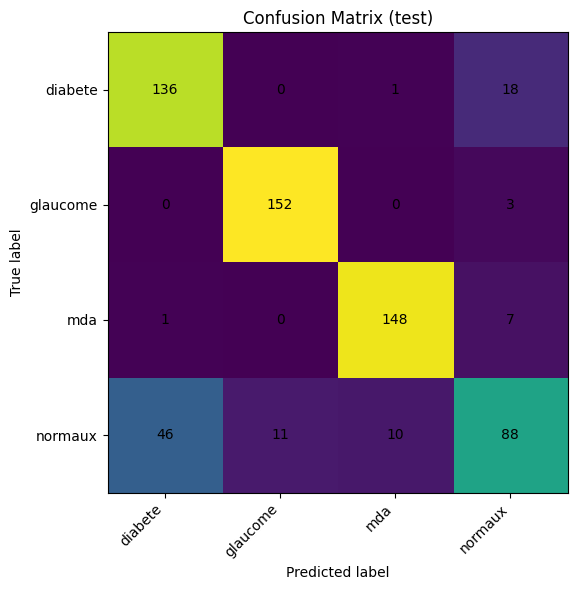


=== Classification report (test) ===
              precision    recall  f1-score   support

     diabete     0.7432    0.8774    0.8047       155
    glaucome     0.9325    0.9806    0.9560       155
         mda     0.9308    0.9487    0.9397       156
     normaux     0.7586    0.5677    0.6494       155

    accuracy                         0.8438       621
   macro avg     0.8413    0.8436    0.8375       621
weighted avg     0.8414    0.8438    0.8376       621



In [5]:

# =========================
# UTILISATION (après entraînement)
# =========================

# device, model, test_loader, le, num_classes doivent déjà exister dans ton script

y_true, y_pred, y_proba = predict_on_loader(model, test_loader, device)

# ---- Matrice de confusion + noms (texte)
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in le.classes_],
    columns=[f"Pred_{c}" for c in le.classes_]
)
print("\n=== Confusion Matrix (test) avec labels ===")
print(cm_df)

# ---- Matrice de confusion (figure)
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix (test)")

# ---- Rapport complet
print("\n=== Classification report (test) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))


In [6]:
import numpy as np
from PIL import Image
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    """
    img: PIL RGB
    thr: seuil (0-255). Plus haut => enlève plus (attention à ne pas rogner l'image utile)
    pad: marge ajoutée autour du crop
    """
    arr = np.array(img)  # H,W,3 uint8
    gray = arr.mean(axis=2)  # H,W

    mask = gray > thr  # True = zone utile
    if not mask.any():
        return img  # image totalement sombre -> on ne touche pas

    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()

    # padding + clamp aux bords
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)

    return img.crop((x0, y0, x1 + 1, y1 + 1))

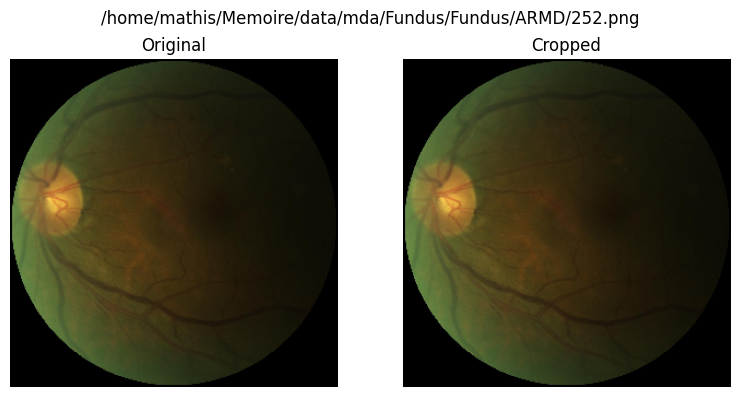

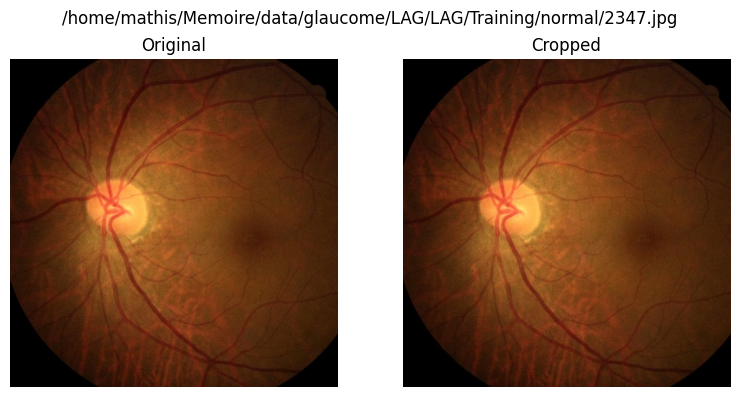

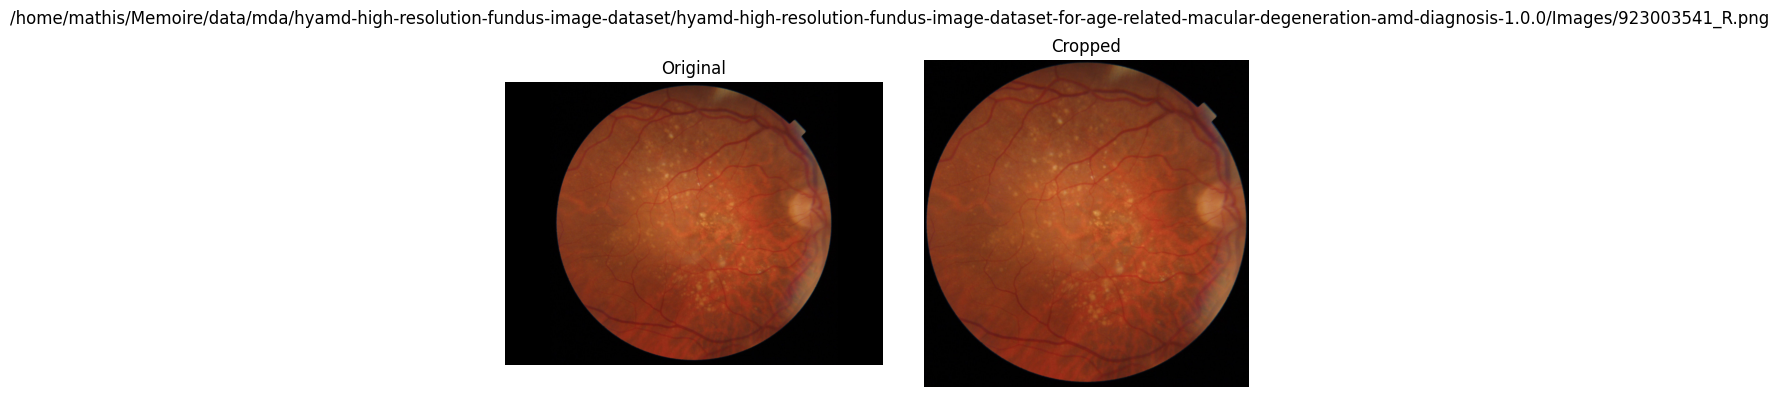

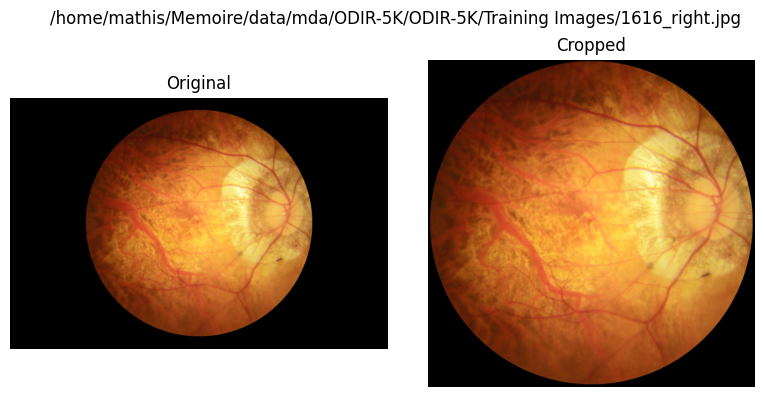

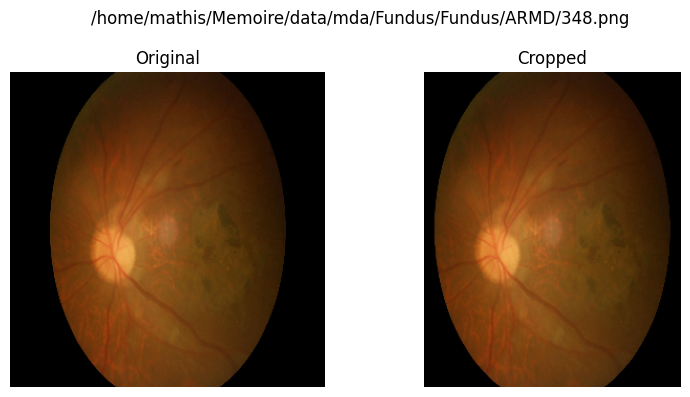

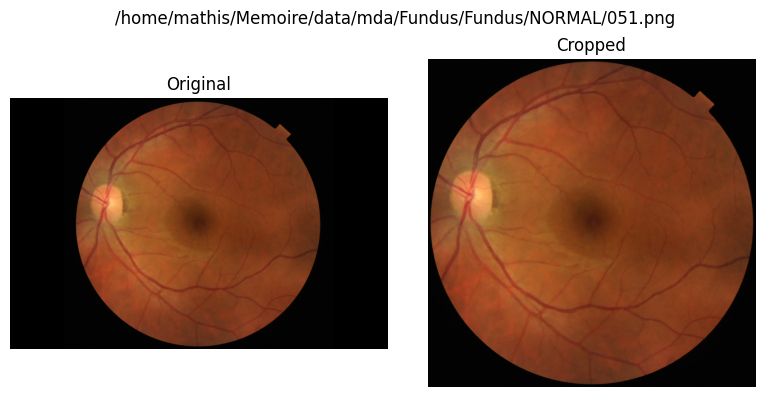

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

sample_paths = df["path"].sample(6, random_state=0).tolist()

for p in sample_paths:
    img = Image.open(p).convert("RGB")
    cropped = crop_black_border_pil(img, thr=10, pad=10)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(cropped)
    axes[1].set_title("Cropped")
    axes[1].axis("off")

    fig.suptitle(p)
    plt.tight_layout()
    plt.show()


In [8]:
# -------------------------
# 2) Encoder les labels
# -------------------------
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

# -------------------------
# 3) Split train/val/test (80/10/10)
# -------------------------
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["y"] if num_classes > 1 else None
)

test_df, val_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["y"] if num_classes > 1 else None
)

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

# -------------------------
# 4) Dataset + Transforms
# -------------------------
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None, do_crop=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.do_crop = do_crop

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        y = int(row["y"])

        img = Image.open(path).convert("RGB")

        if self.do_crop:
            img = crop_black_border_pil(img, thr=10, pad=10)

        if self.transform:
            img = self.transform(img)

        return img, y


train_ds  = FundusDataset(train_df, transform=train_tfms)
val_ds    = FundusDataset(val_df,   transform=val_tfms)
test_ds   = FundusDataset(test_df,  transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# -------------------------
# 5) Modèle (Transfer Learning)
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

# -------------------------
# 6) Entraînement + Évaluation
# -------------------------
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return running_loss / total, correct / total

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total

best_val_acc = 0.0
epochs = 10

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f}")

Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Train : 4966 | Val : 621 | Test : 621
Epoch 01 | train loss 0.6069 acc 0.7392 | val loss 0.4715 acc 0.8068
Epoch 02 | train loss 0.4213 acc 0.8182 | val loss 0.4384 acc 0.8019
Epoch 03 | train loss 0.3442 acc 0.8552 | val loss 0.4714 acc 0.7762
Epoch 04 | train loss 0.3043 acc 0.8733 | val loss 0.3726 acc 0.8502
Epoch 05 | train loss 0.2573 acc 0.8923 | val loss 0.3956 acc 0.8277
Epoch 06 | train loss 0.2229 acc 0.9035 | val loss 0.5892 acc 0.7665
Epoch 07 | train loss 0.2006 acc 0.9174 | val loss 0.4187 acc 0.8196
Epoch 08 | train loss 0.1281 acc 0.9531 | val loss 0.4027 acc 0.8599
Epoch 09 | train loss 0.0804 acc 0.9742 | val loss 0.4444 acc 0.8551
Epoch 10 | train loss 0.0686 acc 0.9778 | val loss 0.4857 acc 0.8583



=== Confusion Matrix (test) avec labels ===
               Pred_diabete  Pred_glaucome  Pred_mda  Pred_normaux
True_diabete            141              0         0            14
True_glaucome             0            152         0             3
True_mda                  3              0       146             7
True_normaux             39             13        14            89


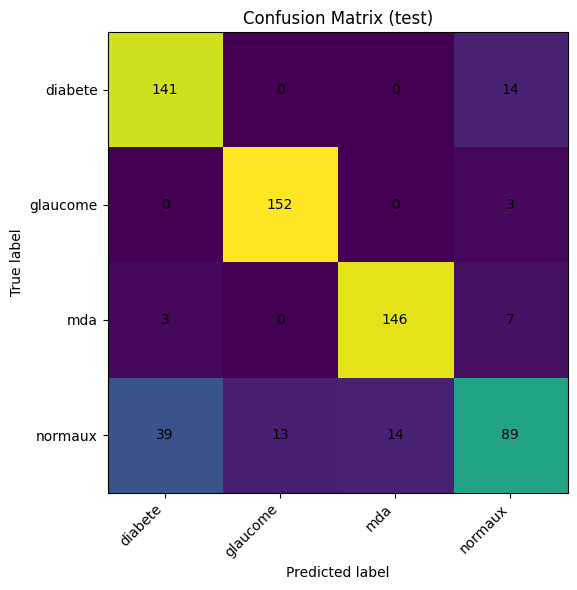


=== Classification report (test) ===
              precision    recall  f1-score   support

     diabete     0.7705    0.9097    0.8343       155
    glaucome     0.9212    0.9806    0.9500       155
         mda     0.9125    0.9359    0.9241       156
     normaux     0.7876    0.5742    0.6642       155

    accuracy                         0.8502       621
   macro avg     0.8480    0.8501    0.8431       621
weighted avg     0.8481    0.8502    0.8433       621



In [9]:
y_true, y_pred, y_proba = predict_on_loader(model, test_loader, device)

# ---- Matrice de confusion + noms (texte)
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in le.classes_],
    columns=[f"Pred_{c}" for c in le.classes_]
)
print("\n=== Confusion Matrix (test) avec labels ===")
print(cm_df)

# ---- Matrice de confusion (figure)
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix (test)")

# ---- Rapport complet
print("\n=== Classification report (test) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))


2026-04-03 17:34:01.125980: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Nombre d'images mal classées : 93


I0000 00:00:1775230444.516571  210805 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4133 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6


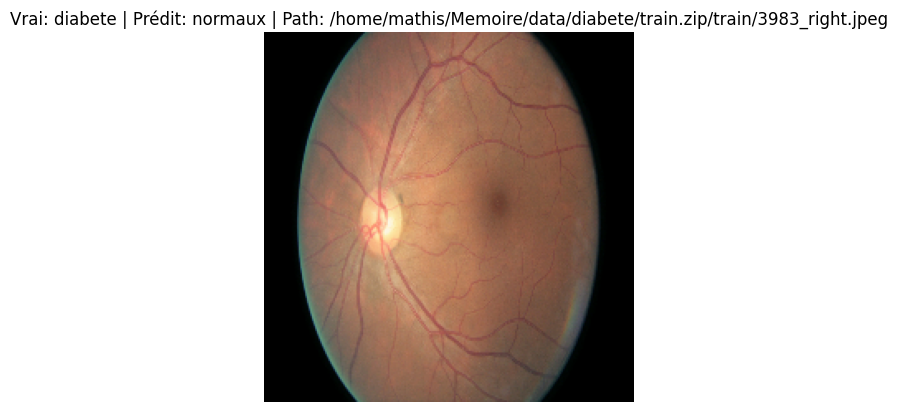

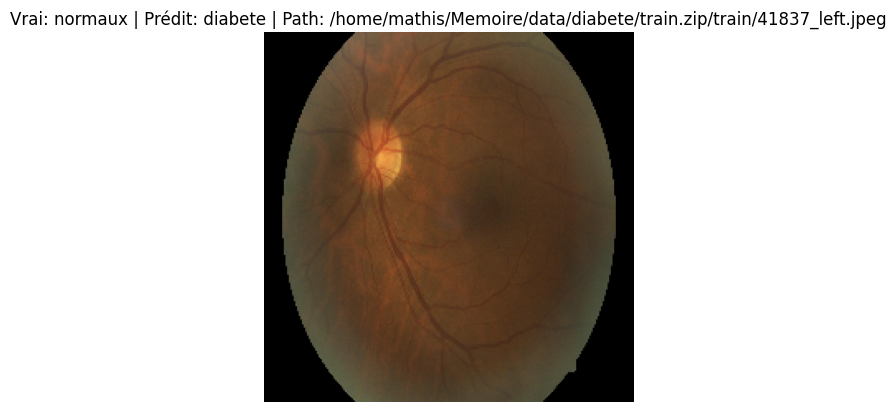

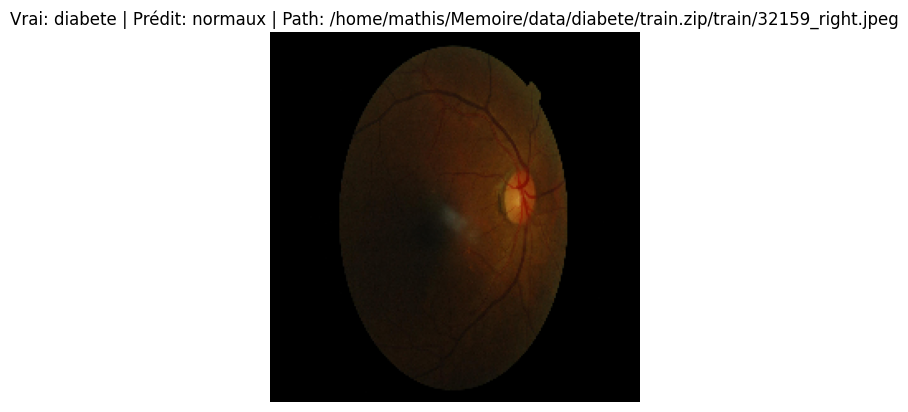

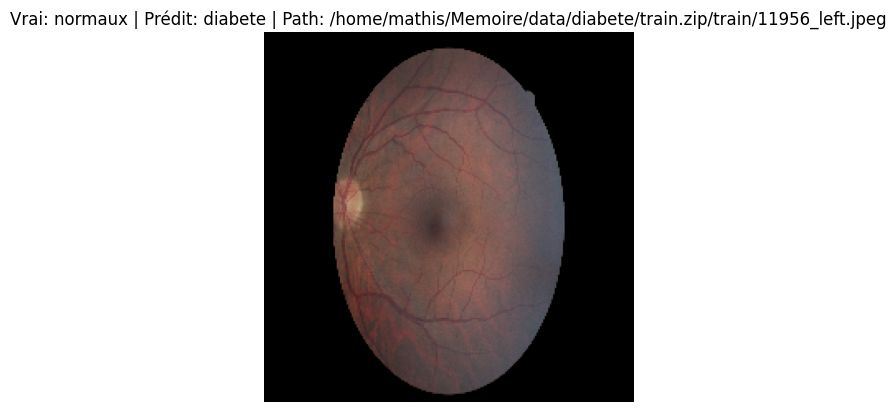

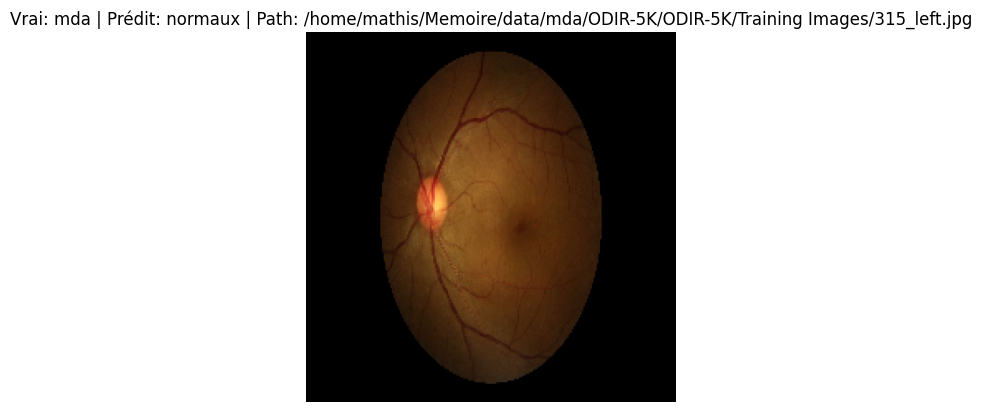

In [10]:
#montre des exemples d'images mal classées
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
df_test = test_df.reset_index(drop=True)
classes = le.classes_
IMG = 224
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'images mal classées : {len(misclassified_indices)}")   
for idx in misclassified_indices[:5]:  # Affiche les 5 premières erreurs
    img_path = df_test.iloc[idx]['path']
    true_label = classes[y_true[idx]]
    pred_label = classes[y_pred[idx]]

    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, [IMG, IMG])

    plt.imshow(img.numpy().astype("uint8"))
    plt.title(f"Vrai: {true_label} | Prédit: {pred_label} | Path: {img_path}")
    plt.axis("off")
    plt.show()

In [11]:

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=5, factor=0.5)

best_val_acc = 0.0
early_stop_patience = 11
epochs_no_improve = 0
epochs = 200

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        epochs_no_improve = 0

    else:
        epochs_no_improve += 1

    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} train acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} val acc {va_acc:.4f} | "
          f"lr {current_lr:.2e} "
          )

    if epochs_no_improve >= early_stop_patience:
        print(f"Early stopping déclenché à l'epoch {epoch}")
        break



Epoch 01 | train loss 0.1225 train acc 0.9525 | val loss 0.4772 val acc 0.8438 | lr 1.00e-04 
Epoch 02 | train loss 0.1164 train acc 0.9549 | val loss 0.5127 val acc 0.8325 | lr 1.00e-04 
Epoch 03 | train loss 0.0920 train acc 0.9666 | val loss 0.4992 val acc 0.8599 | lr 1.00e-04 
Epoch 04 | train loss 0.1171 train acc 0.9551 | val loss 0.5371 val acc 0.8309 | lr 1.00e-04 
Epoch 05 | train loss 0.0926 train acc 0.9686 | val loss 0.5568 val acc 0.8277 | lr 1.00e-04 
Epoch 06 | train loss 0.0638 train acc 0.9746 | val loss 0.5721 val acc 0.8357 | lr 1.00e-04 
Epoch 07 | train loss 0.0844 train acc 0.9672 | val loss 0.5963 val acc 0.8325 | lr 1.00e-04 
Epoch 08 | train loss 0.0807 train acc 0.9704 | val loss 0.6064 val acc 0.8422 | lr 1.00e-04 
Epoch 09 | train loss 0.0603 train acc 0.9787 | val loss 0.5892 val acc 0.8325 | lr 5.00e-05 
Epoch 10 | train loss 0.0298 train acc 0.9917 | val loss 0.5715 val acc 0.8454 | lr 5.00e-05 
Epoch 11 | train loss 0.0205 train acc 0.9954 | val loss 0.5

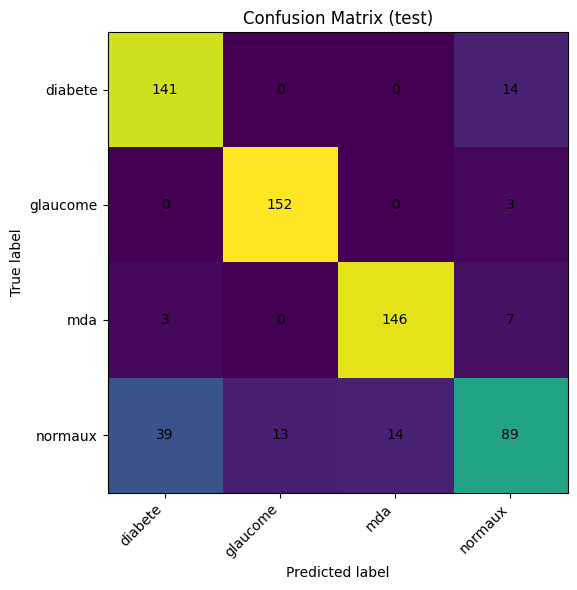

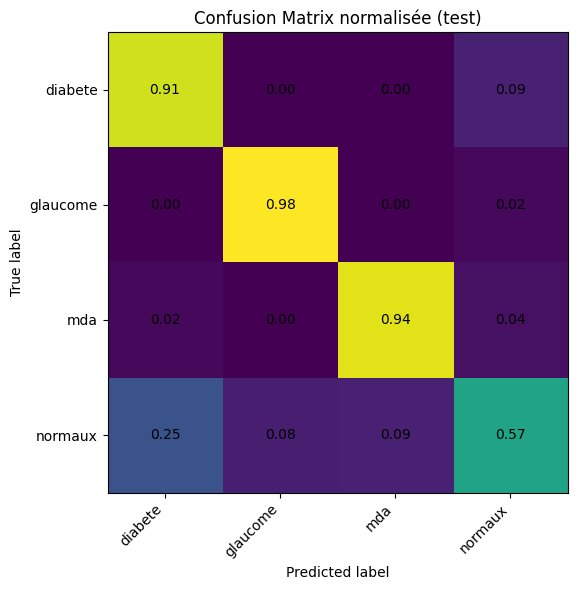


=== Classification report (test) ===
              precision    recall  f1-score   support

     diabete     0.7742    0.7742    0.7742       155
    glaucome     0.9172    1.0000    0.9568       155
         mda     0.9250    0.9487    0.9367       156
     normaux     0.7080    0.6258    0.6644       155

    accuracy                         0.8374       621
   macro avg     0.8311    0.8372    0.8330       621
weighted avg     0.8312    0.8374    0.8332       621



In [12]:
y_true, y_pred, y_proba = predict_on_loader(model, test_loader, device)

cm = confusion_matrix(y_true, y_pred)

# ---- Matrice de confusion (figure)
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix (test)")
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix normalisée (test)", normalize=True)

# ---- Rapport complet
print("\n=== Classification report (test) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))

Nombre d'images mal classées : 101


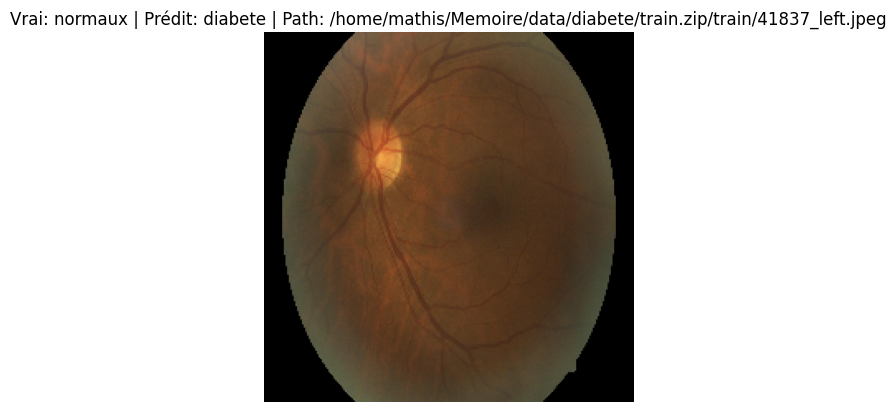

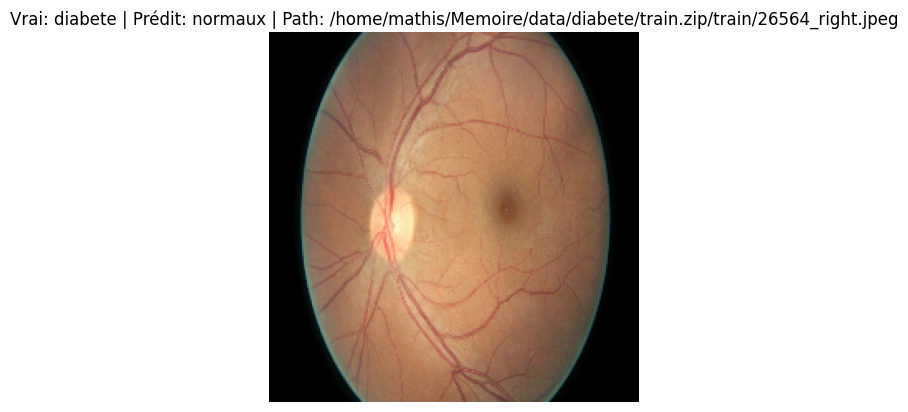

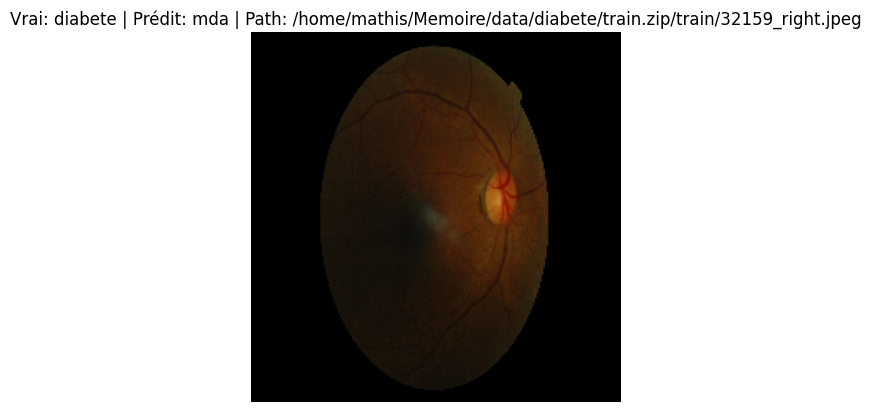

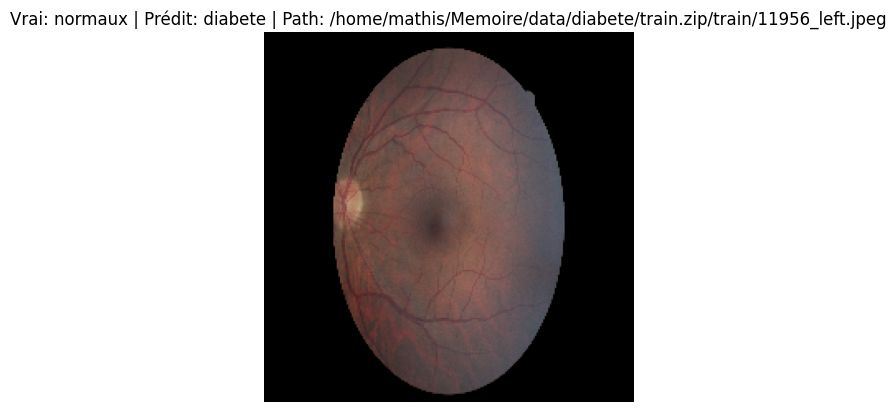

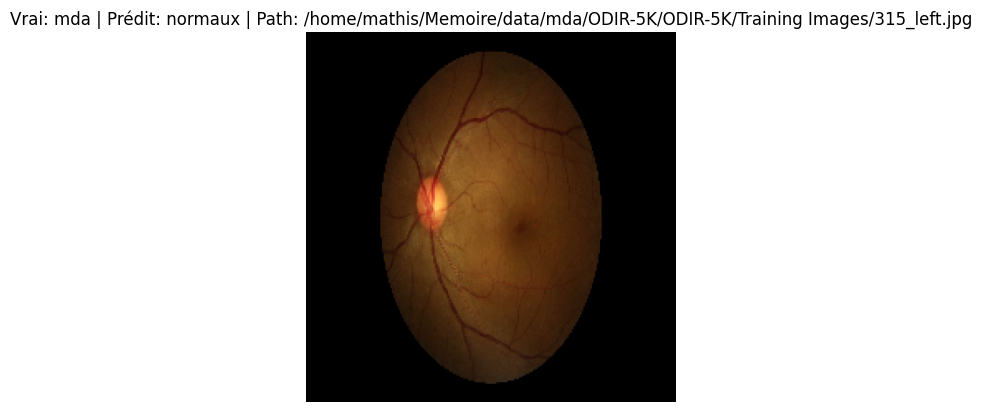

In [13]:
#montre des exemples d'images mal classées
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
df_test = test_df.reset_index(drop=True)
classes = le.classes_
IMG = 224
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'images mal classées : {len(misclassified_indices)}")   
for idx in misclassified_indices[:5]:  # Affiche les 5 premières erreurs
    img_path = df_test.iloc[idx]['path']
    true_label = classes[y_true[idx]]
    pred_label = classes[y_pred[idx]]

    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, [IMG, IMG])

    plt.imshow(img.numpy().astype("uint8"))
    plt.title(f"Vrai: {true_label} | Prédit: {pred_label} | Path: {img_path}")
    plt.axis("off")
    plt.show()